<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana1/Semana1Dia3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carregando o dataset de imagens (Fashion-MNIST)...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Tamanho do Treino: (60000, 28, 28) (60.000 imagens de 28x28 pixels)
Tamanho do Teste: (10000, 28, 28)
--------------------------------------------------


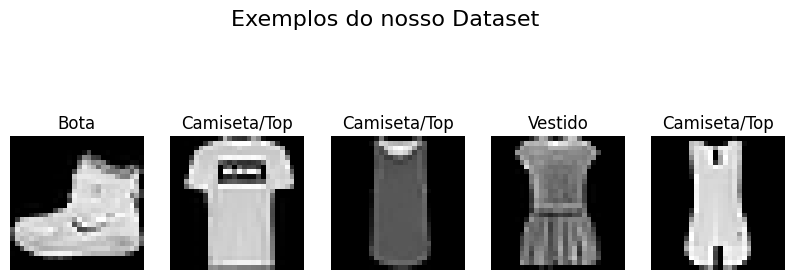

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

# =====================================================================
# ETAPA 1: Carregamento dos Dados (Imagens do E-commerce)
# =====================================================================
print("Carregando o dataset de imagens (Fashion-MNIST)...")
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Nomes das 10 categorias de produtos
class_names = ['Camiseta/Top', 'Calça', 'Suéter', 'Vestido', 'Casaco',
               'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']

print(f"Tamanho do Treino: {X_train.shape} (60.000 imagens de 28x28 pixels)")
print(f"Tamanho do Teste: {X_test.shape}")
print("-" * 50)

# Visualizando algumas imagens de exemplo
plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Exemplos do nosso Dataset", fontsize=16)
plt.show()

In [2]:
# =====================================================================
# ETAPA 2: Pré-processamento (O StandardScaler das Imagens)
# =====================================================================
print("Normalizando os pixels...")
# Pixels vão de 0 (preto) a 255 (branco). Redes Neurais odeiam números grandes.
# Dividimos por 255 para que tudo fique numa escala de 0.0 a 1.0.
X_train = X_train / 255.0
X_test = X_test / 255.0

# CNNs esperam uma dimensão extra para as cores (Canais).
# Como as imagens são em preto e branco, adicionamos um canal "1" no final.
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

Normalizando os pixels...


In [4]:
# =====================================================================
# ETAPA 3: Construção da Rede Neural Convolucional (CNN)
# =====================================================================
print("Construindo a arquitetura da CNN...")

modelo = models.Sequential([
    # Camada 1: O "Olho" da rede. Extrai bordas e texturas.
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)), # Reduz a imagem pela metade, focando no principal

    # Camada 2: Extrai padrões mais complexos (como a forma de uma manga ou sola)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Camada 3: Transição da imagem para vetor (achatamento)
    layers.Flatten(),

    # Camada 4: O cérebro que toma a decisão (Rede Densa Clássica)
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 saídas (uma probabilidade para cada categoria)
])

# Compilando o modelo
modelo.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(modelo.summary()) # Mostra um resumo da arquitetura na tela
print("-" * 50)

Construindo a arquitetura da CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

None
--------------------------------------------------


In [5]:
# =====================================================================
# ETAPA 4: Treinamento (Ao Vivo)
# =====================================================================
print("\nIniciando o treinamento da Rede Neural...")
# Definimos epochs=3 para ser super rápido na apresentação ao vivo (leva cerca de 20-30 seg)
historico = modelo.fit(X_train, y_train, epochs=3, validation_split=0.2)


Iniciando o treinamento da Rede Neural...
Epoch 1/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.8241 - loss: 0.4896 - val_accuracy: 0.8759 - val_loss: 0.3575
Epoch 2/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.8817 - loss: 0.3271 - val_accuracy: 0.8822 - val_loss: 0.3275
Epoch 3/3
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms/step - accuracy: 0.8983 - loss: 0.2792 - val_accuracy: 0.8925 - val_loss: 0.3002



=== AVALIAÇÃO DETALHADA: DEEP LEARNING ===
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Acurácia no mundo real (Teste): 89.30%

Relatório de Classificação:
              precision    recall  f1-score   support

Camiseta/Top       0.80      0.90      0.85      1000
       Calça       0.98      0.98      0.98      1000
      Suéter       0.85      0.83      0.84      1000
     Vestido       0.90      0.90      0.90      1000
      Casaco       0.82      0.82      0.82      1000
    Sandália       0.96      0.98      0.97      1000
      Camisa       0.73      0.64      0.68      1000
       Tênis       0.95      0.95      0.95      1000
       Bolsa       0.97      0.98      0.97      1000
        Bota       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Gerando Matriz de Confusão visual...


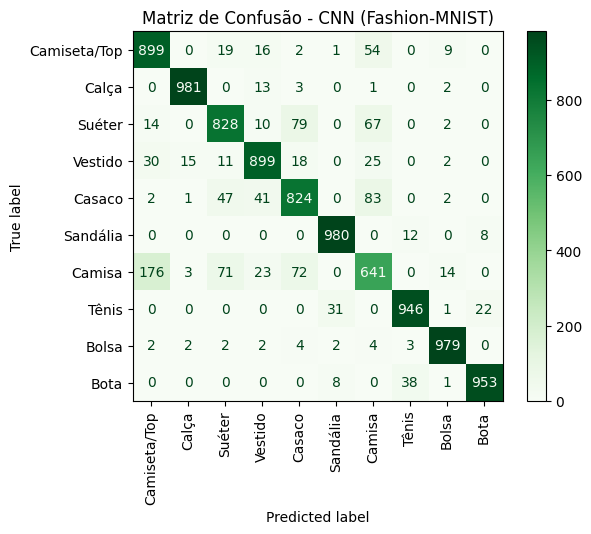

In [ ]:
# =====================================================================
# ETAPA 5: Avaliação usando ferramentas do Machine Learning Clássico
# =====================================================================
print("\n=== AVALIAÇÃO DETALHADA: DEEP LEARNING ===")

# A rede neural retorna probabilidades. Precisamos pegar a categoria com maior chance (argmax)
previsoes_prob = modelo.predict(X_test)
previsoes_classes = np.argmax(previsoes_prob, axis=1)

print(f"\nAcurácia no mundo real (Teste): {accuracy_score(y_test, previsoes_classes) * 100:.2f}%\n")

# Reutilizando o Classification Report do Dia 1 e 2!
print("Relatório de Classificação:")
print(classification_report(y_test, previsoes_classes, target_names=class_names))

# Matriz de Confusão
print("Gerando Matriz de Confusão visual...")
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, previsoes_classes,
    display_labels=class_names,
    cmap='Greens',
    xticks_rotation='vertical'
)
plt.title('Matriz de Confusão - CNN (Fashion-MNIST)')
plt.show()